In [1]:
## Loading the data and getting an initial look at some of the first few values

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("Nat_Gas.csv")
df.head()

,Dates,Prices
0,10/31/20,10.1
1,11/30/20,10.3
2,12/31/20,11.0
3,1/31/21,10.9
4,2/28/21,10.9


## Convert dates and prepare the data

In [3]:
# Convert the Date column to datetime format
df['Dates'] = pd.to_datetime(df['Dates'], format='%m/%d/%y')
df = df.sort_values(by='Dates')
df.set_index('Dates', inplace=True)
df.head()

,Prices
Dates,
2020-10-31,10.1
2020-11-30,10.3
2020-12-31,11.0
2021-01-31,10.9
2021-02-28,10.9


## Visualize the data

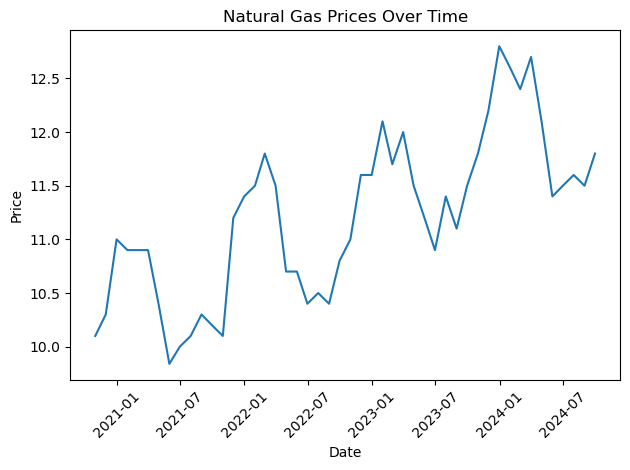

In [4]:
plt.figure()
plt.plot(df.index, df['Prices'])
# Labels and title
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Natural Gas Prices Over Time")

# Rotate and format dates
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Interpolate prices for any date

In [5]:
# Interpolate daily prices
daily_prices = df['Prices'].resample('D').interpolate(method='linear')
daily_prices = daily_prices.to_frame(name='Prices')
daily_prices.head(10)

,Prices
Dates,
2020-10-31,10.100000
2020-11-01,10.106667
2020-11-02,10.113333
2020-11-03,10.120000
2020-11-04,10.126667
2020-11-05,10.133333
2020-11-06,10.140000
2020-11-07,10.146667
2020-11-08,10.153333


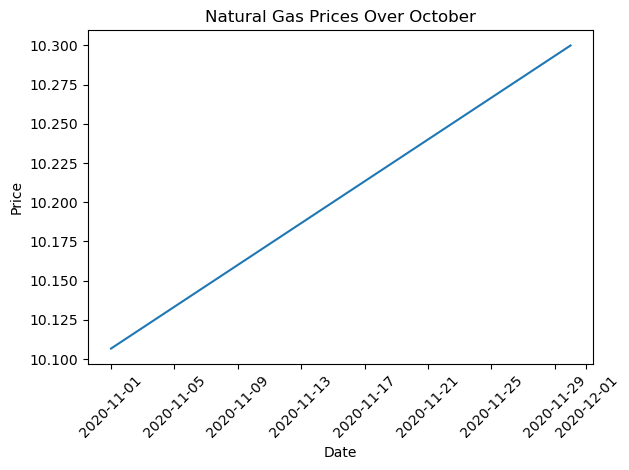

In [6]:
dateVar = daily_prices.loc['2020-11-01':'2020-11-30']
plt.figure()
plt.plot(dateVar.index, dateVar['Prices'])
# Labels and title
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Natural Gas Prices Over October")

# Rotate and format dates
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Extrapolate Data

In [7]:
daily_df = daily_prices
daily_df['Month'] = daily_df.index.month
# Calculate average price for each month
monthly_avg = daily_df.groupby('Month')['Prices'].mean()

# Create future dates (next 365 days)
future_dates = pd.date_range(
    start=daily_df.index.max() + pd.Timedelta(days=1),
    periods=365
)

# Assign prices based on month averages
future_prices = [monthly_avg[date.month] for date in future_dates]

# Create future DataFrame
future_df = pd.DataFrame({'Prices': future_prices}, index=future_dates)

# Combine past + future
full_prices = pd.concat([daily_df[['Prices']], future_df])

# Check last rows
full_prices.tail()

,Prices
2025-09-26,10.954167
2025-09-27,10.954167
2025-09-28,10.954167
2025-09-29,10.954167
2025-09-30,10.954167


## Function 

In [8]:
def get_price(date):
    date = pd.to_datetime(date)
    
    if date in full_prices.index:
        return full_prices.loc[date, 'Prices']
    else:
        return "Date out of range"

In [9]:
date = input("Enter a date (MM/DD/YYYY): ")
get_price(date)

Enter a date (MM/DD/YYYY):  1


ValueError: Given date string "1" not likely a datetime, at position 0

In [10]:
full_prices.to_csv("full_gas_prices.csv")